# Phase 4: external-donor validation of the original PBMC3k XGBoost model

This notebook evaluates the finalized PBMC3k/Donor-1 XGBoost pipeline on all annotated PBMC4k/Donor-2 singlets. PBMC4k is used as one untouched external test donor—there is no random PBMC4k train/test split and no model fitting or tuning.

The original PBMC3k model is loaded read-only, hashed before and after prediction, and never overwritten. All new outputs are written under `PBMC4k/`.

## Interpretation boundary

PBMC4k labels are human-reviewed marker-based working annotations, not independent laboratory ground truth. The original model has nine PBMC3k classes and has never seen the PBMC4k dendritic class. Results are therefore reported in two ways:

- **Shared-class external validation:** evaluates cells whose reviewed PBMC4k label exists in the original model.
- **All-cell behavior:** includes dendritic cells to show what a closed-set model does when forced to classify an unseen population.

Dendritic predictions are analyzed as out-of-distribution behavior, not as evidence that the original model knew this class.

In [1]:
from pathlib import Path
import hashlib
import json

import anndata as ad
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import display
from scipy import sparse
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    matthews_corrcoef,
)

LOW_CONFIDENCE_THRESHOLD = 0.50
FIGURE_DPI = 160

ad.settings.allow_write_nullable_strings = True
sc.settings.verbosity = 2
sc.set_figure_params(dpi=110, facecolor="white", frameon=False)
sns.set_theme(style="whitegrid", context="notebook")

## 1. Locate and load the frozen model and PBMC4k annotations

In [2]:
cwd = Path.cwd().resolve()
analysis_root = next(
    (
        base
        for base in (cwd, *cwd.parents)
        if (base / "PBMC3k" / "models" / "pbmc_cell_classifier.joblib").is_file()
        and (base / "PBMC4k" / "data" / "processed" / "pbmc4k_phase3_annotated.h5ad").is_file()
    ),
    None,
)
if analysis_root is None:
    raise FileNotFoundError("Could not locate the PBMC3k model and PBMC4k annotated object.")

PBMC3K = analysis_root / "PBMC3k"
PBMC4K = analysis_root / "PBMC4k"
MODEL_PATH = PBMC3K / "models" / "pbmc_cell_classifier.joblib"
METADATA_PATH = PBMC3K / "models" / "pbmc_cell_classifier_metadata.json"
INPUT = PBMC4K / "data" / "processed" / "pbmc4k_phase3_annotated.h5ad"
OUTPUT = PBMC4K / "data" / "processed" / "pbmc4k_phase4_xgboost_external_validation.h5ad"
FIGURES = PBMC4K / "results" / "figures"
TABLES = PBMC4K / "results" / "tables"
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

model_hash_before = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()
model = joblib.load(MODEL_PATH)
with METADATA_PATH.open() as handle:
    metadata = json.load(handle)
adata = sc.read_h5ad(INPUT)

requirements = {
    "reviewed PBMC4k labels": "cell_type" in adata.obs,
    "full normalized PBMC4k genes": adata.raw is not None,
    "PBMC4k UMAP": "X_umap" in adata.obsm,
    "frozen pipeline feature count": getattr(model, "n_features_in_", None) == len(metadata["gene_names"]),
    "metadata class count": len(metadata["classes"]) == len(model.classes_),
}
display(pd.Series(requirements, name="available").to_frame())
if not all(requirements.values()):
    raise ValueError("The model schema or PBMC4k annotation input is incomplete.")

print("PBMC4k input:", adata)
print("Frozen PBMC3k model SHA-256:", model_hash_before)

,available
reviewed PBMC4k labels,True
full normalized PBMC4k genes,True
PBMC4k UMAP,True
frozen pipeline feature count,True
metadata class count,True


PBMC4k input: AnnData object with n_obs × n_vars = 4131 × 2000
    obs: 'dataset', 'original_barcode', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'pass_min_genes', 'pass_max_genes', 'pass_mt', 'pass_qc', 'doublet_score', 'predicted_doublet', 'original_leiden', 'leiden', 'cell_type', 'annotation_confidence'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'expression_mean', 'expression_std', 'std_rank', 'selected_by_pbmc4k_std', 'mean', 'std'
    uns: 'cell_type_annotation', 'cell_type_colors', 'dendrogram_leiden', 'doublet_filtering', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'original_leiden_colors', 'pca', 'phase2b_reclustering', 'rank_genes_groups_leiden_singlets', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log_normalized'
    obsp: 'connectivities', 'distances'
Frozen PBMC3k model SHA-256: cc8701edbb1b3726d788307acf8384e213594f414d47c3edf24eebc257ea1

## 2. Validate class and feature schemas

PBMC4k genes are reordered to match the exact PBMC3k training feature order. Training genes absent from PBMC4k are represented by all-zero sparse columns; extra PBMC4k genes are not passed to the frozen pipeline.

In [3]:
model_genes = pd.Index(metadata["gene_names"], dtype=str)
model_classes = np.asarray(metadata["classes"], dtype=str)
pipeline_classes = np.asarray(model.classes_)
if not np.array_equal(pipeline_classes, np.arange(len(model_classes))):
    raise ValueError("Pipeline numeric classes do not match metadata class ordering.")

pbmc4k_genes = pd.Index(adata.raw.var_names.astype(str))
source_positions = pbmc4k_genes.get_indexer(model_genes)
present_mask = source_positions >= 0
missing_model_genes = model_genes[~present_mask]
extra_pbmc4k_genes = pbmc4k_genes.difference(model_genes)

true_labels = adata.obs["cell_type"].astype(str)
pbmc4k_classes = pd.Index(sorted(true_labels.unique()))
shared_classes = pd.Index([label for label in pbmc4k_classes if label in set(model_classes)])
unseen_pbmc4k_classes = pbmc4k_classes.difference(model_classes)
model_classes_absent_from_pbmc4k = pd.Index(model_classes).difference(pbmc4k_classes)

schema_summary = pd.Series(
    {
        "PBMC3k model input genes": len(model_genes),
        "model genes present in PBMC4k": int(present_mask.sum()),
        "model genes missing from PBMC4k": int((~present_mask).sum()),
        "extra PBMC4k genes not used": len(extra_pbmc4k_genes),
        "original model classes": len(model_classes),
        "PBMC4k reviewed classes": len(pbmc4k_classes),
        "shared classes present in PBMC4k": len(shared_classes),
        "PBMC4k classes unseen by model": ", ".join(unseen_pbmc4k_classes) or "None",
        "model classes absent from PBMC4k": ", ".join(model_classes_absent_from_pbmc4k) or "None",
    },
    name="External-validation schema",
)
display(schema_summary.to_frame())

pd.Series(missing_model_genes, name="missing_model_gene").to_csv(
    TABLES / "pbmc4k_phase4_missing_model_genes.csv", index=False
)

,External-validation schema
PBMC3k model input genes,13656
model genes present in PBMC4k,12897
model genes missing from PBMC4k,759
extra PBMC4k genes not used,3464
original model classes,9
PBMC4k reviewed classes,9
shared classes present in PBMC4k,8
PBMC4k classes unseen by model,Dendritic cells
model classes absent from PBMC4k,Platelets


## 3. Construct the sparse PBMC4k matrix in PBMC3k feature order

In [4]:
raw_expression = adata.raw.X
raw_expression = sparse.csr_matrix(raw_expression) if not sparse.issparse(raw_expression) else raw_expression.tocsr()
present_expression = raw_expression[:, source_positions[present_mask]].tocoo()
destination_columns = np.flatnonzero(present_mask)[present_expression.col]
X_external = sparse.csr_matrix(
    (present_expression.data, (present_expression.row, destination_columns)),
    shape=(adata.n_obs, len(model_genes)),
    dtype=np.float64,
)

if X_external.shape[1] != model.n_features_in_:
    raise ValueError("Aligned external matrix does not match the frozen pipeline feature count.")
print(f"Aligned matrix: {X_external.shape[0]:,} cells × {X_external.shape[1]:,} genes")
print(f"Sparse nonzero values: {X_external.nnz:,}")

Aligned matrix: 4,131 cells × 13,656 genes
Sparse nonzero values: 5,058,742


## 4. Predict PBMC4k cell types with the untouched PBMC3k model

In [5]:
encoded_predictions = np.asarray(model.predict(X_external), dtype=int)
probabilities = np.asarray(model.predict_proba(X_external), dtype=float)
predicted_labels = model_classes[encoded_predictions]
max_probability = probabilities.max(axis=1)
normalized_entropy = -np.sum(
    probabilities * np.log(np.clip(probabilities, 1e-12, 1.0)), axis=1
) / np.log(probabilities.shape[1])

known_to_model = true_labels.isin(model_classes).to_numpy()
prediction_correct = predicted_labels == true_labels.to_numpy()
prediction_frame = pd.DataFrame(
    {
        "cell_id": adata.obs_names,
        "leiden": adata.obs["leiden"].astype(str).to_numpy(),
        "reviewed_cell_type": true_labels.to_numpy(),
        "predicted_cell_type": predicted_labels,
        "model_knows_reviewed_class": known_to_model,
        "prediction_correct": prediction_correct,
        "max_probability": max_probability,
        "normalized_entropy": normalized_entropy,
        "low_confidence": max_probability < LOW_CONFIDENCE_THRESHOLD,
    }
).set_index("cell_id")
for class_index, class_name in enumerate(model_classes):
    safe_name = class_name.lower().replace("+", "plus").replace(" ", "_").replace("/", "_")
    prediction_frame[f"probability_{safe_name}"] = probabilities[:, class_index]

prediction_frame.to_csv(TABLES / "pbmc4k_phase4_xgboost_cell_predictions.csv")
display(prediction_frame.head())

,leiden,reviewed_cell_type,predicted_cell_type,model_knows_reviewed_class,prediction_correct,max_probability,normalized_entropy,low_confidence,probability_activated_transitional_t_cells,probability_b_cells,probability_cd16plus_non-classical_monocytes,probability_classical_monocytes,probability_cytotoxic_cd8_t_cells,probability_il7rplus_memory_helper_t_cells,probability_nk_cells,probability_naive_resting_t_cells,probability_platelets
cell_id,,,,,,,,,,,,,,,,,
pbmc4k_AAACCTGAGAAGGCCT-1,0,Classical monocytes,Classical monocytes,True,True,0.999327,0.003130,False,0.000091,0.000208,0.000093,0.999327,0.000029,0.000087,0.000074,0.000045,0.000045
pbmc4k_AAACCTGAGACAGACC-1,1,Classical monocytes,Classical monocytes,True,True,0.999531,0.002236,False,0.000028,0.000071,0.000116,0.999531,0.000024,0.000148,0.000033,0.000026,0.000023
pbmc4k_AAACCTGAGATAGTCA-1,0,Classical monocytes,Classical monocytes,True,True,0.998667,0.005568,False,0.000149,0.000382,0.000558,0.998667,0.000034,0.000048,0.000090,0.000027,0.000044
pbmc4k_AAACCTGAGCGCCTCA-1,2,IL7R+ memory/helper T cells,IL7R+ memory/helper T cells,True,True,0.899034,0.218235,False,0.009913,0.003338,0.003542,0.002534,0.034401,0.899034,0.004114,0.040522,0.002603
pbmc4k_AAACCTGAGGCATGGT-1,3,Activated/transitional T cells,Naive/resting T cells,True,False,0.936133,0.121566,False,0.001186,0.000946,0.000687,0.001069,0.000588,0.058263,0.000643,0.936133,0.000485


## 5. External-donor metrics

Shared-class metrics exclude only cells whose reviewed label is impossible for the original model to output. No cells are removed based on whether their prediction was correct or confident.

In [6]:
y_true_all = true_labels.to_numpy()
y_pred_all = predicted_labels
y_true_shared = y_true_all[known_to_model]
y_pred_shared = y_pred_all[known_to_model]
shared_labels_present = [label for label in model_classes if label in set(y_true_shared)]

external_metrics = pd.Series(
    {
        "PBMC4k cells evaluated": adata.n_obs,
        "shared-class PBMC4k cells": int(known_to_model.sum()),
        "unseen-class PBMC4k cells": int((~known_to_model).sum()),
        "all-cell forced-choice accuracy": accuracy_score(y_true_all, y_pred_all),
        "shared-class accuracy": accuracy_score(y_true_shared, y_pred_shared),
        "shared-class balanced accuracy": balanced_accuracy_score(y_true_shared, y_pred_shared),
        "shared-class macro F1": f1_score(
            y_true_shared,
            y_pred_shared,
            labels=shared_labels_present,
            average="macro",
            zero_division=0,
        ),
        "shared-class weighted F1": f1_score(
            y_true_shared, y_pred_shared, average="weighted", zero_division=0
        ),
        "shared-class MCC": matthews_corrcoef(y_true_shared, y_pred_shared),
        "mean maximum probability": max_probability.mean(),
        "low-confidence cells": int((max_probability < LOW_CONFIDENCE_THRESHOLD).sum()),
        "low-confidence percent": 100 * np.mean(max_probability < LOW_CONFIDENCE_THRESHOLD),
        "original PBMC3k internal-test accuracy": metadata["test_accuracy"],
        "original PBMC3k internal-test macro F1": metadata["test_macro_f1"],
    },
    name="External-donor validation",
)
external_metrics.to_csv(TABLES / "pbmc4k_phase4_xgboost_external_metrics.csv")
display(external_metrics.to_frame())

/Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC3k/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,External-donor validation
PBMC4k cells evaluated,4131.000000
shared-class PBMC4k cells,4097.000000
unseen-class PBMC4k cells,34.000000
all-cell forced-choice accuracy,0.686759
shared-class accuracy,0.692458
shared-class balanced accuracy,0.801035
shared-class macro F1,0.715813
shared-class weighted F1,0.652787
shared-class MCC,0.698967
mean maximum probability,0.935085


## 6. Per-class results and confusion matrices

,precision,recall,f1-score,support
Activated/transitional T cells,0.600000,0.002791,0.005556,1075.000000
B cells,0.993289,1.000000,0.996633,592.000000
CD16+ non-classical monocytes,0.980198,0.933962,0.956522,106.000000
Classical monocytes,0.993485,0.991333,0.992408,923.000000
Cytotoxic CD8 T cells,0.927342,0.824830,0.873087,588.000000
IL7R+ memory/helper T cells,0.642216,0.975000,0.774368,440.000000
NK cells,0.972603,0.784530,0.868502,181.000000
Naive/resting T cells,0.151675,0.895833,0.259427,192.000000
Platelets,0.000000,0.000000,0.000000,0.000000
accuracy,0.692458,0.692458,0.692458,0.692458


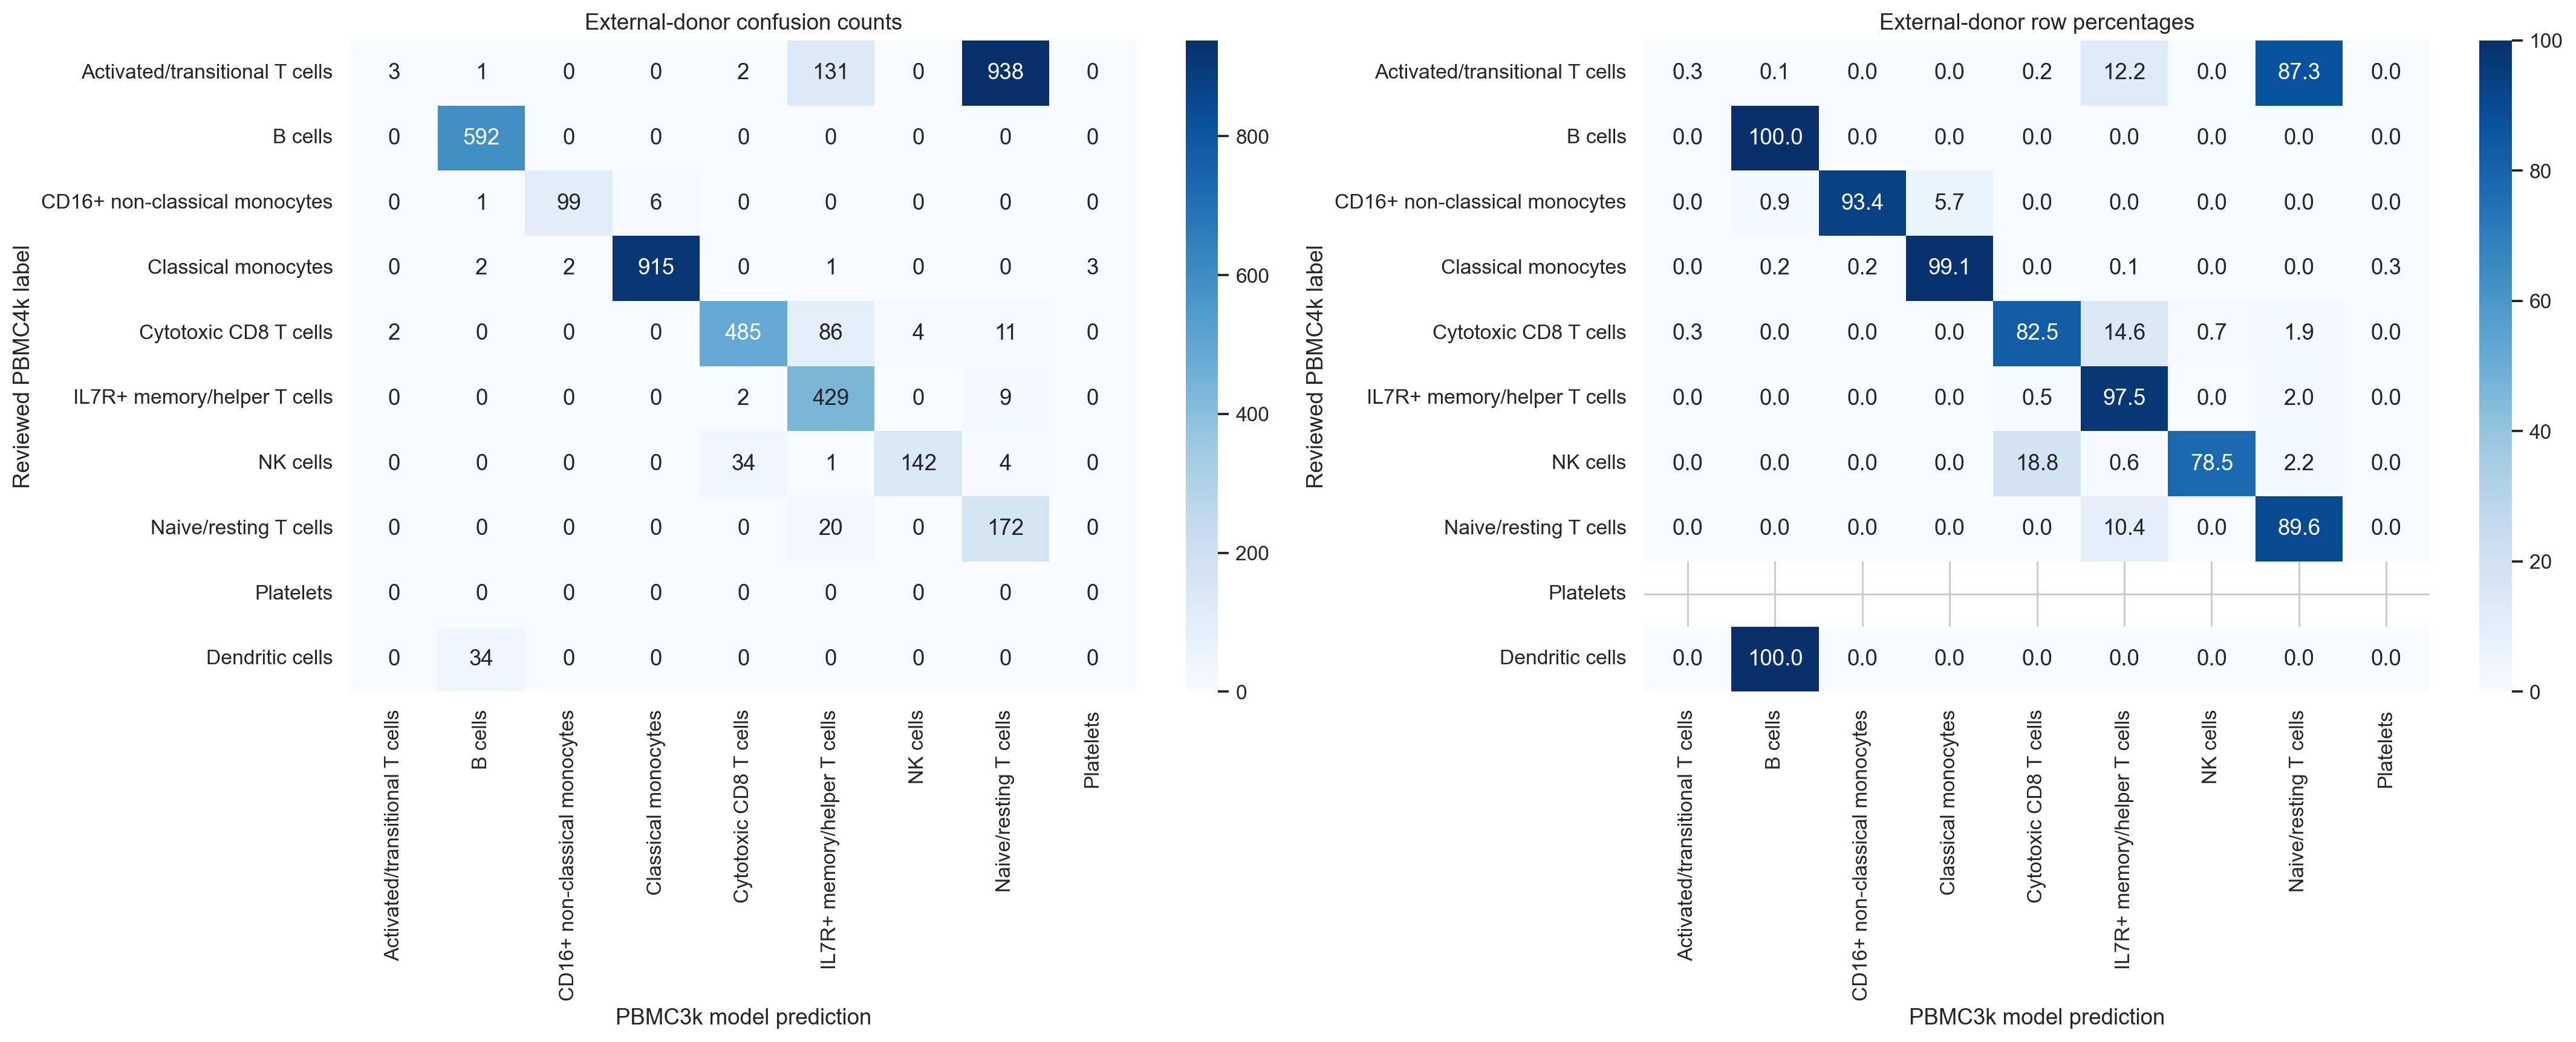

In [7]:
report = classification_report(
    y_true_shared,
    y_pred_shared,
    labels=list(model_classes),
    output_dict=True,
    zero_division=0,
)
per_class_report = pd.DataFrame(report).T
per_class_report.to_csv(TABLES / "pbmc4k_phase4_xgboost_per_class_report.csv")
display(per_class_report)

true_display_order = list(model_classes) + [
    label for label in unseen_pbmc4k_classes if label not in set(model_classes)
]
confusion_counts = pd.crosstab(
    pd.Categorical(y_true_all, categories=true_display_order, ordered=True),
    pd.Categorical(y_pred_all, categories=model_classes, ordered=True),
    rownames=["Reviewed PBMC4k label"],
    colnames=["PBMC3k model prediction"],
    dropna=False,
)
confusion_row_percent = confusion_counts.div(confusion_counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
confusion_counts.to_csv(TABLES / "pbmc4k_phase4_xgboost_confusion_counts.csv")
confusion_row_percent.to_csv(TABLES / "pbmc4k_phase4_xgboost_confusion_row_percent.csv")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(confusion_counts, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("External-donor confusion counts")
sns.heatmap(confusion_row_percent, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100, ax=axes[1])
axes[1].set_title("External-donor row percentages")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase4_xgboost_confusion_matrices.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

## 7. Unseen dendritic population and prediction confidence

Because the original model has no dendritic output class, this section asks which known classes it chooses and whether its probabilities reveal uncertainty.

In [8]:
unseen_mask = ~known_to_model
unseen_behavior = (
    prediction_frame.loc[unseen_mask]
    .groupby(["reviewed_cell_type", "predicted_cell_type"], observed=True)
    .agg(
        cells=("predicted_cell_type", "size"),
        median_max_probability=("max_probability", "median"),
        mean_max_probability=("max_probability", "mean"),
        low_confidence_cells=("low_confidence", "sum"),
    )
    .reset_index()
)
if not unseen_behavior.empty:
    unseen_behavior["percent_within_reviewed_class"] = (
        100 * unseen_behavior["cells"] / unseen_behavior.groupby("reviewed_cell_type")["cells"].transform("sum")
    )
unseen_behavior.to_csv(TABLES / "pbmc4k_phase4_unseen_class_behavior.csv", index=False)
display(unseen_behavior.style.format({
    "median_max_probability": "{:.3f}",
    "mean_max_probability": "{:.3f}",
    "percent_within_reviewed_class": "{:.1f}%",
}))

confidence_summary = (
    prediction_frame.groupby(["reviewed_cell_type", "model_knows_reviewed_class"], observed=True)
    .agg(
        cells=("max_probability", "size"),
        mean_max_probability=("max_probability", "mean"),
        median_max_probability=("max_probability", "median"),
        low_confidence_percent=("low_confidence", "mean"),
    )
)
confidence_summary["low_confidence_percent"] *= 100
confidence_summary.to_csv(TABLES / "pbmc4k_phase4_confidence_by_reviewed_type.csv")
display(confidence_summary.style.format({
    "mean_max_probability": "{:.3f}",
    "median_max_probability": "{:.3f}",
    "low_confidence_percent": "{:.1f}%",
}))

,reviewed_cell_type,predicted_cell_type,cells,median_max_probability,mean_max_probability,low_confidence_cells,percent_within_reviewed_class
0,Dendritic cells,B cells,34,0.962,0.944,0,100.0%


,,cells,mean_max_probability,median_max_probability,low_confidence_percent
reviewed_cell_type,model_knows_reviewed_class,,,,
Activated/transitional T cells,True,1075,0.879,0.940,0.9%
B cells,True,592,0.996,0.999,0.0%
CD16+ non-classical monocytes,True,106,0.953,0.997,0.9%
Classical monocytes,True,923,0.990,0.999,0.3%
Cytotoxic CD8 T cells,True,588,0.902,0.965,2.4%
Dendritic cells,False,34,0.944,0.962,0.0%
IL7R+ memory/helper T cells,True,440,0.950,0.988,0.5%
NK cells,True,181,0.890,0.970,5.0%
Naive/resting T cells,True,192,0.893,0.969,1.6%


## 8. Visualize external predictions and compare internal versus external scores

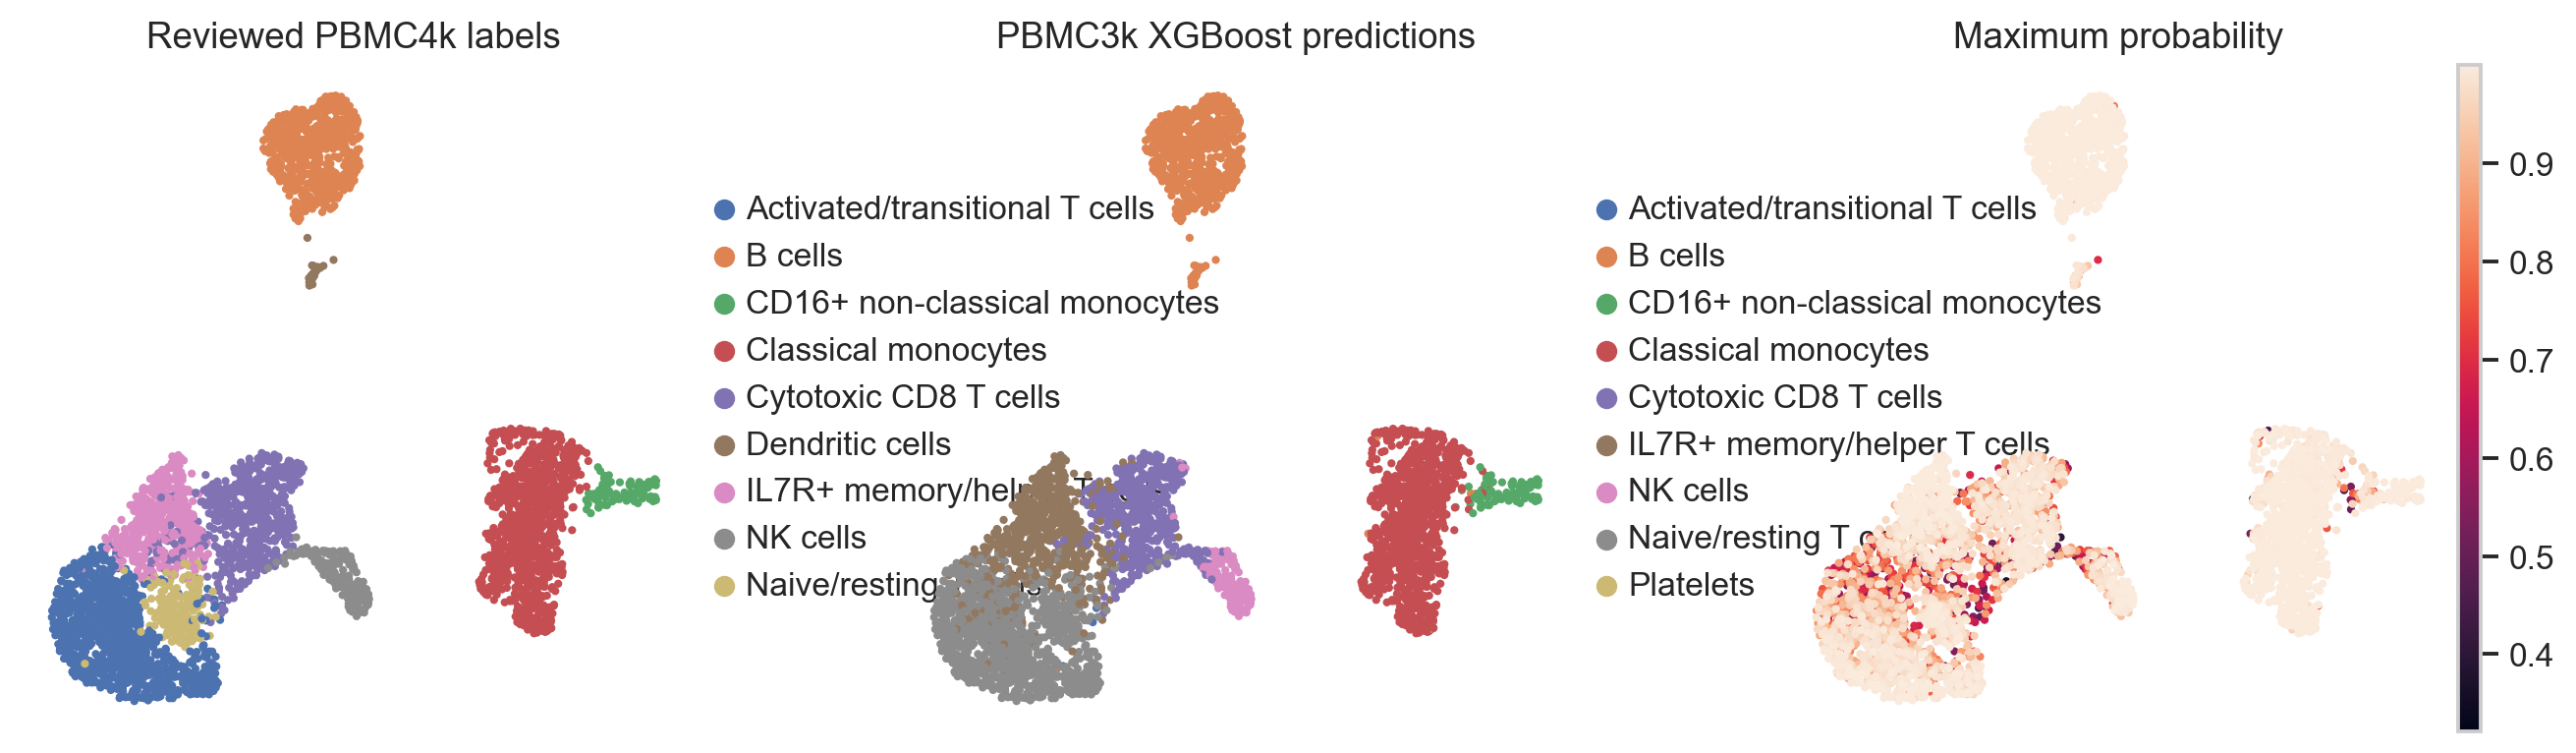

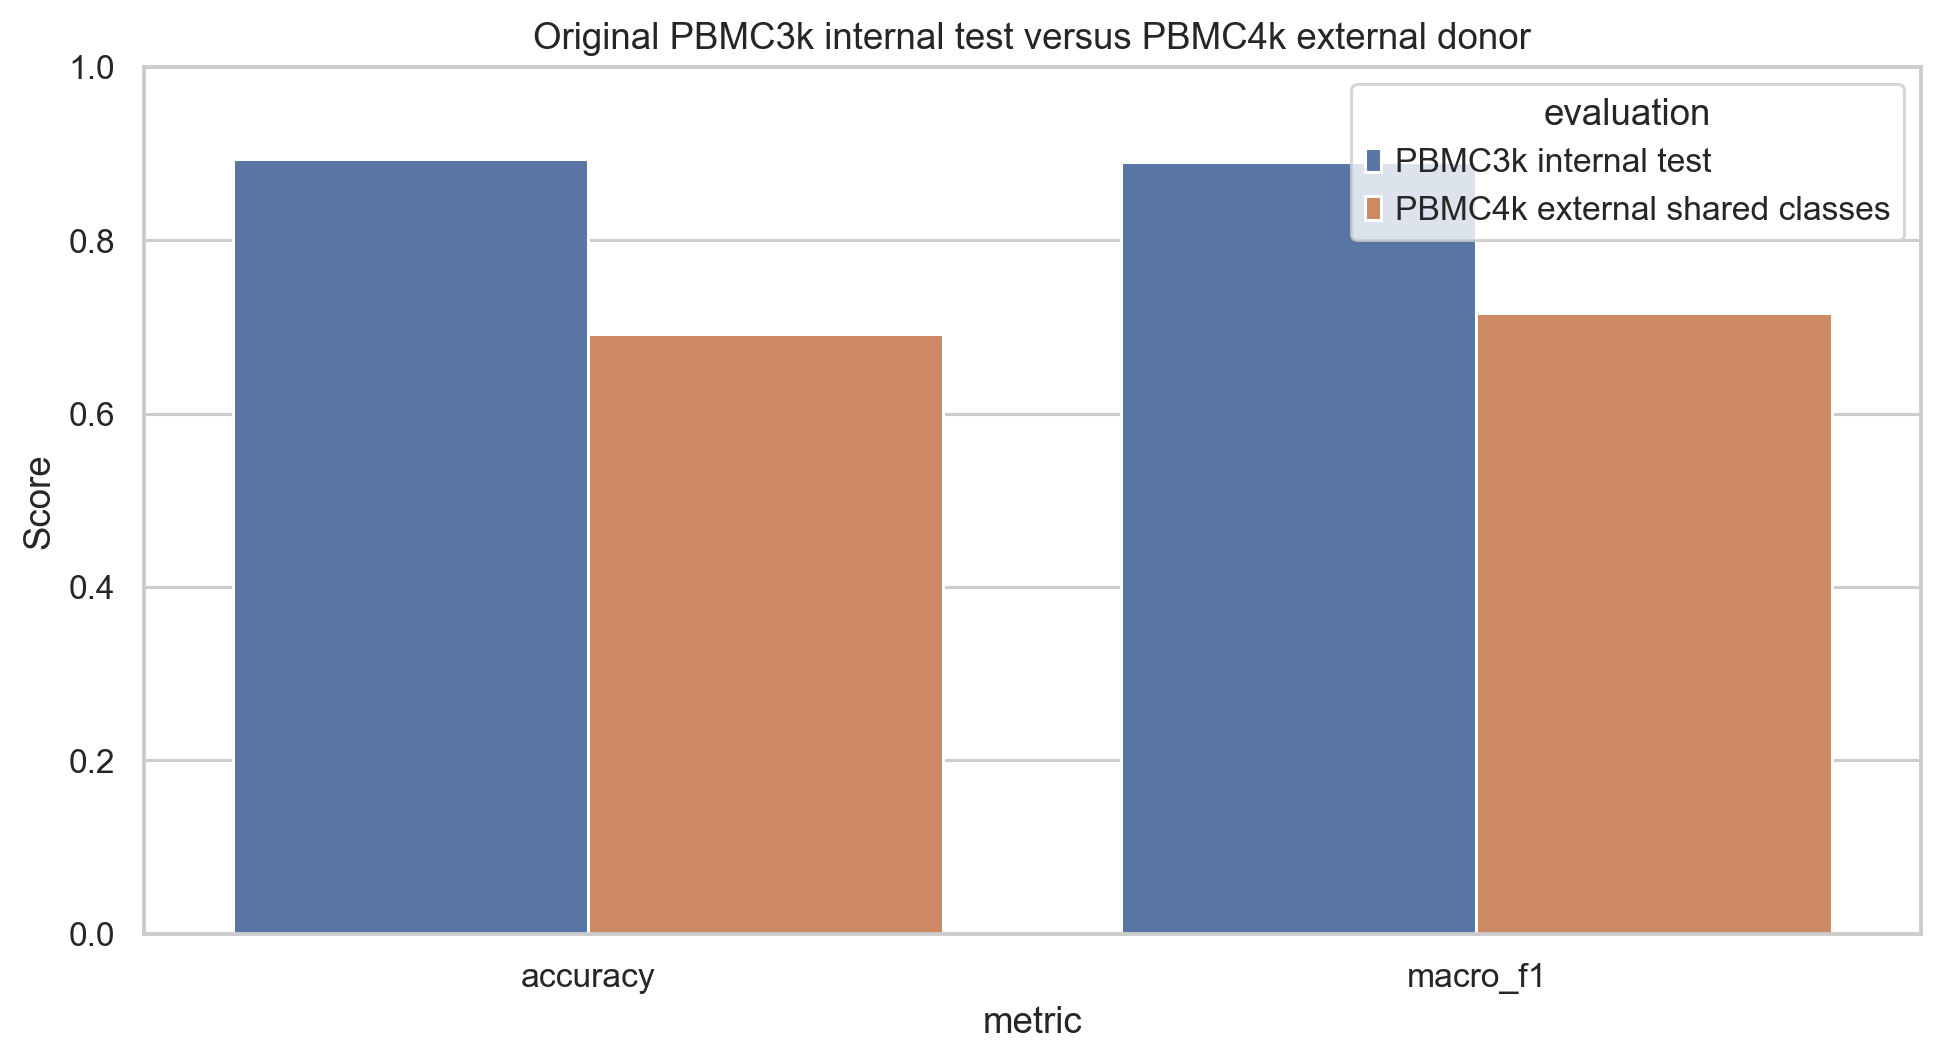

In [9]:
adata.obs["xgboost_prediction"] = pd.Categorical(predicted_labels, categories=model_classes)
adata.obs["xgboost_max_probability"] = max_probability
adata.obs["xgboost_low_confidence"] = max_probability < LOW_CONFIDENCE_THRESHOLD
adata.obs["xgboost_prediction_correct"] = prediction_correct
adata.obs["xgboost_reviewed_class_known"] = known_to_model

sc.pl.umap(
    adata,
    color=["cell_type", "xgboost_prediction", "xgboost_max_probability"],
    ncols=3,
    title=["Reviewed PBMC4k labels", "PBMC3k XGBoost predictions", "Maximum probability"],
    show=False,
)
plt.savefig(FIGURES / "pbmc4k_phase4_xgboost_prediction_umaps.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

score_comparison = pd.DataFrame(
    {
        "evaluation": ["PBMC3k internal test", "PBMC4k external shared classes"],
        "accuracy": [metadata["test_accuracy"], external_metrics["shared-class accuracy"]],
        "macro_f1": [metadata["test_macro_f1"], external_metrics["shared-class macro F1"]],
    }
)
score_comparison.to_csv(TABLES / "pbmc4k_phase4_internal_external_score_comparison.csv", index=False)
score_long = score_comparison.melt(id_vars="evaluation", var_name="metric", value_name="score")
plt.figure(figsize=(9, 5))
sns.barplot(data=score_long, x="metric", y="score", hue="evaluation")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Original PBMC3k internal test versus PBMC4k external donor")
plt.tight_layout()
plt.savefig(FIGURES / "pbmc4k_phase4_internal_external_scores.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

## 9. Cluster-versus-prediction agreement

In [10]:
cluster_prediction_counts = pd.crosstab(
    adata.obs["leiden"].astype(str),
    adata.obs["xgboost_prediction"].astype(str),
    rownames=["Leiden cluster"],
    colnames=["XGBoost prediction"],
)
cluster_prediction_percent = cluster_prediction_counts.div(
    cluster_prediction_counts.sum(axis=1), axis=0
) * 100
cluster_prediction_counts.to_csv(TABLES / "pbmc4k_phase4_cluster_prediction_counts.csv")
cluster_prediction_percent.to_csv(TABLES / "pbmc4k_phase4_cluster_prediction_percent.csv")
display(cluster_prediction_percent.style.format("{:.1f}%").background_gradient(cmap="Blues", axis=1))

XGBoost prediction,Activated/transitional T cells,B cells,CD16+ non-classical monocytes,Classical monocytes,Cytotoxic CD8 T cells,IL7R+ memory/helper T cells,NK cells,Naive/resting T cells,Platelets
Leiden cluster,,,,,,,,,
0,0.0%,0.0%,0.0%,98.4%,0.0%,0.0%,0.0%,0.0%,1.6%
1,0.0%,0.3%,0.3%,99.3%,0.0%,0.1%,0.0%,0.0%,0.0%
2,0.0%,0.0%,0.0%,0.0%,0.5%,97.5%,0.0%,2.0%,0.0%
3,0.3%,0.1%,0.0%,0.0%,0.2%,12.2%,0.0%,87.3%,0.0%
4,0.3%,0.0%,0.0%,0.0%,82.5%,14.6%,0.7%,1.9%,0.0%
5,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
6,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
7,0.0%,0.0%,0.0%,0.0%,18.8%,0.6%,78.5%,2.2%,0.0%
8,0.0%,0.0%,0.0%,0.0%,0.0%,10.4%,0.0%,89.6%,0.0%


## 10. Verify model preservation and save the prediction-augmented PBMC4k object

In [11]:
model_hash_after = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()
if model_hash_after != model_hash_before:
    raise RuntimeError("The original PBMC3k model artifact changed during external validation.")

adata.uns["xgboost_external_validation"] = {
    "training_donor": "PBMC3k / Donor 1",
    "external_test_donor": "PBMC4k / Donor 2",
    "model_path": str(MODEL_PATH),
    "model_sha256": model_hash_before,
    "model_modified": False,
    "pbmc4k_split": "none; every annotated singlet is external test data",
    "shared_class_accuracy": float(external_metrics["shared-class accuracy"]),
    "shared_class_macro_f1": float(external_metrics["shared-class macro F1"]),
    "unseen_pbmc4k_classes": list(unseen_pbmc4k_classes),
    "marker_labels_are_independent_ground_truth": False,
}
adata.write_h5ad(OUTPUT, compression="gzip")

print("Original PBMC3k model preserved with SHA-256:", model_hash_after)
print("Saved PBMC4k prediction object:", OUTPUT)
print(f"Output size: {OUTPUT.stat().st_size / 1024**2:.1f} MB")

Original PBMC3k model preserved with SHA-256: cc8701edbb1b3726d788307acf8384e213594f414d47c3edf24eebc257ea1465
Saved PBMC4k prediction object: /Users/Ema/Desktop/cosmos/26-the-backpropagators-analysis/PBMC4k/data/processed/pbmc4k_phase4_xgboost_external_validation.h5ad
Output size: 63.3 MB
